# This Notebook Benchmarks models using my loss function against models using other standard loss functions.

**Testing the Loss Function on classification was only to see in action the property that the loss heavily penalizes error outliers, making the gradient prioritize reducing the largest prediction errors over the average error. The loss function is not designed for classification tasks.**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from tqdm import tqdm

import matplotlib.pyplot as plt

# torch_modules is a library I made that has a lot of useful torch modules, I'm filling it with more modules as I progress
from torch_modules import MyLoss

import sklearn.datasets as datasets
from torch.utils.data import TensorDataset, DataLoader

torch.set_num_threads(8)

In [2]:
N_SAMPLES = 64*192
N_FEATURES = 128
N_TARGET = 48
BATCH_SIZE = 64
EPOCHS = 100
LR = 3e-5

In [3]:
x1, y1 = datasets.make_regression(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES//2,
    n_targets=N_TARGET,
    random_state=123
)

x2, y2 = datasets.make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_FEATURES//2,
    n_redundant=(N_FEATURES//2)-8,
    n_classes=N_TARGET,
    n_clusters_per_class=3,
    flip_y=0.02,
    class_sep=1.2,
    random_state=123
)

x1, y1 = torch.tensor(x1), torch.tensor(y1)
x2, y2 = torch.tensor(x2), torch.tensor(y2)

In [4]:
x1 = x1.view(len(x1)//BATCH_SIZE, BATCH_SIZE, N_FEATURES//2).float()
x2 = x2.view(len(x2)//BATCH_SIZE, BATCH_SIZE, N_FEATURES).float()
x1 = F.normalize(torch.cat([x1, torch.normal(mean=torch.mean(x1, dim=-1, keepdim=True).expand(-1, -1, N_FEATURES//2), std=torch.std(x1, dim=-1, keepdim=True).expand(-1, -1, N_FEATURES//2))], dim=-1), p=2.0, dim=-1)

y1 = F.normalize(y1.view(len(y1)//BATCH_SIZE, BATCH_SIZE, N_TARGET).float(), p=2.0, dim=-1)

y1[:, :, :16] = y1[:, :, :16]*x1[:, :, :16]
y1[:, :, 16:24] = torch.cos(y1[:, :, 16:24]*x1[:, :, 16:24])-y1[:, :, 16:24]

y2 = y2.view(len(y2)//BATCH_SIZE, BATCH_SIZE).long()
y2_ = F.one_hot(y2, num_classes=N_TARGET)

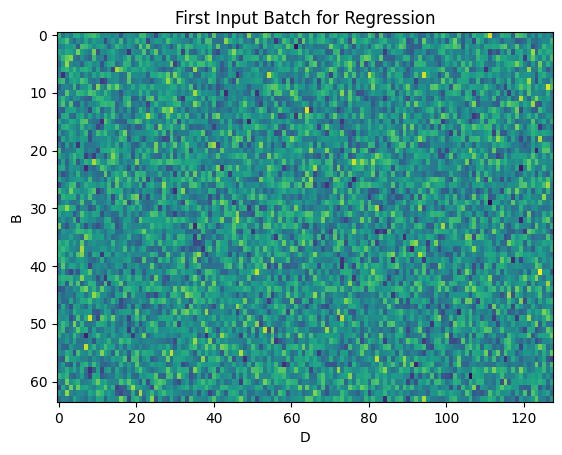

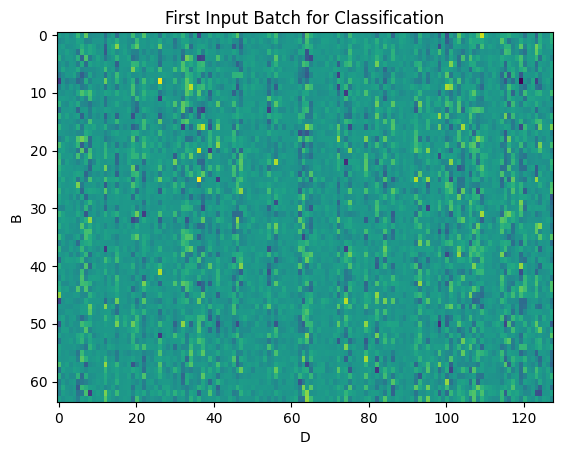

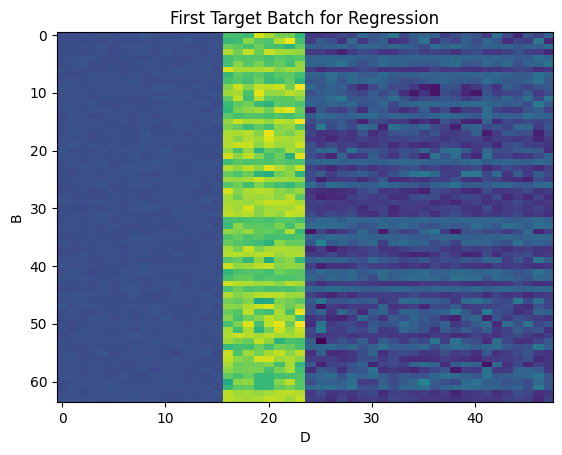

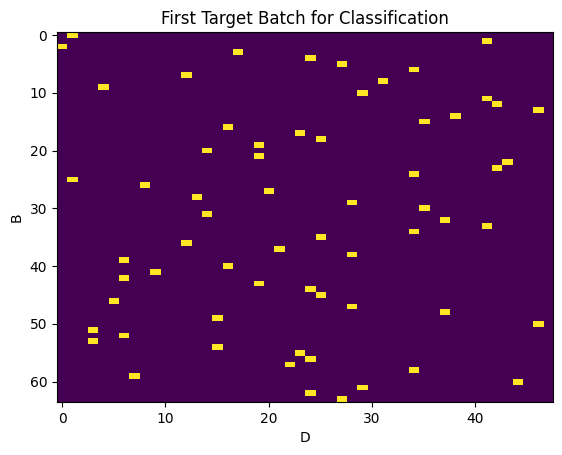

In [5]:
# Plot First batch
plt.imshow(x1[0], aspect='auto', cmap='viridis')
plt.title("First Input Batch for Regression")
plt.xlabel('D')
plt.ylabel('B')
plt.show()

plt.imshow(x2[0], aspect='auto', cmap='viridis')
plt.title("First Input Batch for Classification")
plt.xlabel('D')
plt.ylabel('B')
plt.show()

plt.imshow(y1[0], aspect='auto', cmap='viridis')
plt.title("First Target Batch for Regression")
plt.xlabel('D')
plt.ylabel('B')
plt.show()

plt.imshow(y2_[0], aspect='auto', cmap='viridis')
plt.title("First Target Batch for Classification")
plt.xlabel('D')
plt.ylabel('B')
plt.show()

In [6]:
# General MLP for regression and classification
class MLP(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_in, 192),
            nn.SiLU(),
            nn.Linear(192, 96),
            nn.SiLU(),
            nn.Linear(96, 64),
            nn.SiLU(),
            nn.Linear(64, d_out)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
models = {
    "regression": [
        MLP(N_FEATURES, N_TARGET).train(), # My loss function
        MLP(N_FEATURES, N_TARGET).train(), # MSE Loss
        MLP(N_FEATURES, N_TARGET).train() # L1 Loss
    ],
    "classification": [
        MLP(N_FEATURES, N_TARGET).train(), # My loss function
        MLP(N_FEATURES, N_TARGET).train(), # Cross Entropy
        MLP(N_FEATURES, N_TARGET).train(), # MSE Loss
        MLP(N_FEATURES, N_TARGET).train() # L1 Loss
    ]
}

In [8]:
def train_regression(model, loss_fn, x, y):
    metrics = {"loss_fn": [], "l1_loss": []}

    optimizer = optim.Adam(model.parameters(), lr=LR, maximize=False)
    for epoch in tqdm(range(1, EPOCHS+1), desc='Training'):
        model.train()
        for i in range(len(x)):
            optimizer.zero_grad()
            out = model(x[i])
            loss = loss_fn(out, y[i])
            metrics["loss_fn"].append(loss.item())
            loss.backward()
            optimizer.step()
        metrics["l1_loss"].append(F.l1_loss(model(x), y).item())
    print(f"Final L1 Loss of the whole dataset: {F.l1_loss(model(x), y)}")
    return metrics

def train_classification(model, loss_fn, x, y, y_):
    metrics = {"loss_fn": [], "f1_macro": []}

    optimizer = optim.Adam(model.parameters(), lr=LR, maximize=False)
    for epoch in tqdm(range(1, EPOCHS+1), desc='Training'):
        model.train()
        for i in range(len(x)):
            optimizer.zero_grad()
            out = model(x[i])
            loss = loss_fn(out, y[i])
            metrics["loss_fn"].append(loss.item())
            loss.backward()
            optimizer.step()
        metrics["f1_macro"].append(f1_score(y_.view(-1), torch.argmax(model(x), dim=-1).view(-1), average='macro'))
    print(f"Final F1 Macro of the whole dataset: {f1_score(y_.view(-1), torch.argmax(model(x), dim=-1).view(-1), average='macro')}")
    return metrics

In [9]:
all_metrics_regression = [
    train_regression(models["regression"][0], MyLoss(), x1, y1),
    train_regression(models["regression"][1], F.mse_loss, x1, y1),
    train_regression(models["regression"][2], F.l1_loss, x1, y1)
]

all_metrics_classification = [
    train_classification(models["classification"][0], MyLoss(), x2, y2_, y2),
    train_classification(models["classification"][1], F.cross_entropy, x2, y2, y2),
    train_classification(models["classification"][2], F.mse_loss, x2, y2_.float(), y2),
    train_classification(models["classification"][3], F.l1_loss, x2, y2_.float(), y2)
]

Training: 100%|███████████████████████████████████████████████████████████████████| 100/100 [00:45<00:00,  2.20it/s]


Final L1 Loss of the whole dataset: 0.03339283913373947


Training: 100%|███████████████████████████████████████████████████████████████████| 100/100 [00:41<00:00,  2.44it/s]


Final L1 Loss of the whole dataset: 0.03755658492445946


Training: 100%|███████████████████████████████████████████████████████████████████| 100/100 [00:43<00:00,  2.32it/s]


...

Final F1 Macro of the whole dataset: 0.4066395155200461


Training: 100%|███████████████████████████████████████████████████████████████████| 100/100 [00:42<00:00,  2.33it/s]


Final F1 Macro of the whole dataset: 0.2918255951697124


Training: 100%|███████████████████████████████████████████████████████████████████| 100/100 [00:44<00:00,  2.26it/s]

Final F1 Macro of the whole dataset: 0.012953612060837642


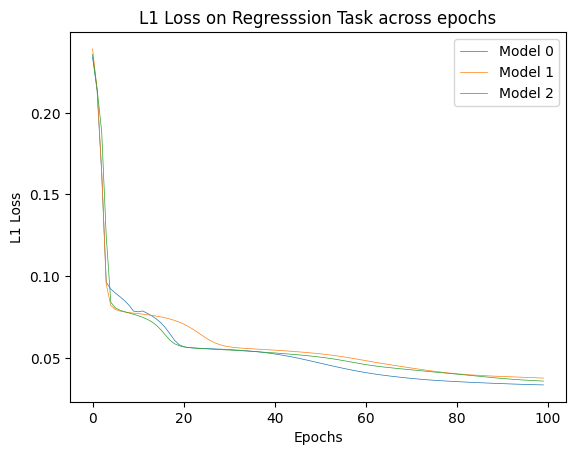

In [10]:
for idx, metrics in enumerate(all_metrics_regression):
    plt.plot(metrics["l1_loss"], label=f"Model {idx}", linewidth=0.5)
plt.title("L1 Loss on Regresssion Task across epochs")
plt.xlabel("Epochs")
plt.ylabel("L1 Loss")
plt.legend()
plt.show()

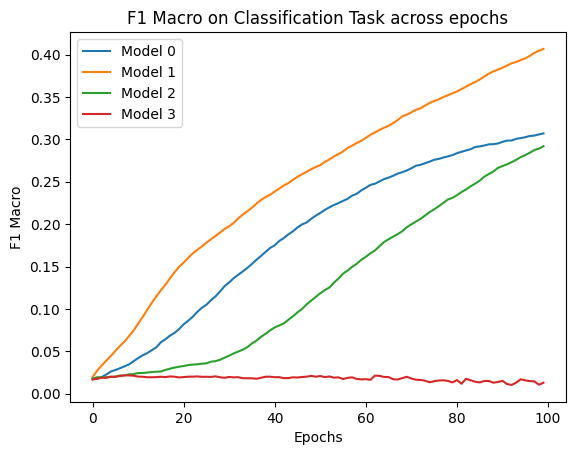

In [11]:
for idx, metrics in enumerate(all_metrics_classification):
    plt.plot(metrics["f1_macro"], label=f"Model {idx}")
plt.title("F1 Macro on Classification Task across epochs")
plt.xlabel("Epochs")
plt.ylabel("F1 Macro")
plt.legend()
plt.show()

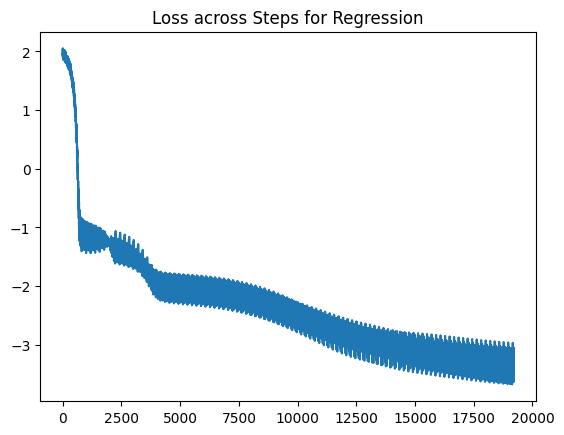

In [12]:
plt.plot(all_metrics_regression[0]['loss_fn'])
plt.title("Loss across Steps for Regression")
plt.show()

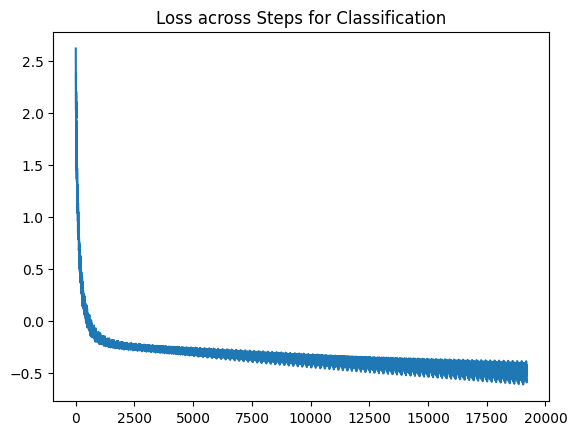

In [13]:
plt.plot(all_metrics_classification[0]["loss_fn"])
plt.title("Loss across Steps for Classification")
plt.show()